Перші 5 рядків датасету:

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0   

Усі стовпці у датасеті:

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'] 


 Точність моделі: 0.9344262295081968

 Звіт по метриках моделі:
               precision    recall  f1-score   support

           1       0.79      0.92      0.85        12

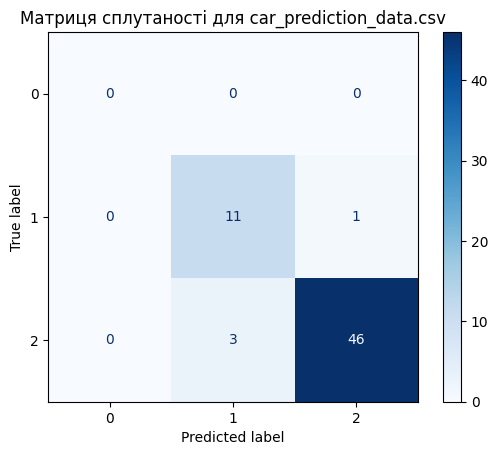

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


df = pd.read_csv("car_prediction_data.csv")

print("Перші 5 рядків датасету:\n")
print(df.head(), "\n")


print("Усі стовпці у датасеті:\n")
print(df.columns.tolist(), "\n")


target_col = 'Fuel_Type'   



label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column].astype(str))
        label_encoders[column] = le


X = df.drop(target_col, axis=1)
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_s, y_train)


y_pred = clf.predict(X_test_s)

print("\n Точність моделі:", accuracy_score(y_test, y_pred))
print("\n Звіт по метриках моделі:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Матриця сплутаності для car_prediction_data.csv")
plt.show()
